# Import Python Modules

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score,recall_score,precision_score,accuracy_score,confusion_matrix,classification_report
from sklearn.impute import SimpleImputer as Imputer
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
import warnings
warnings.simplefilter(action='ignore')

# Data Analysis Part

In [ ]:
df=pd.read_csv("/content/diabetes.csv")

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=768, step=1)

In [ ]:
df.size

6912

In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
209,7,184,84,33,0,35.5,0.355,41,1
293,1,128,48,45,194,40.5,0.613,24,1
377,1,87,60,37,75,37.2,0.509,22,0
611,3,174,58,22,194,32.9,0.593,36,1
401,6,137,61,0,0,24.2,0.151,55,0


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
df['Outcome'].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


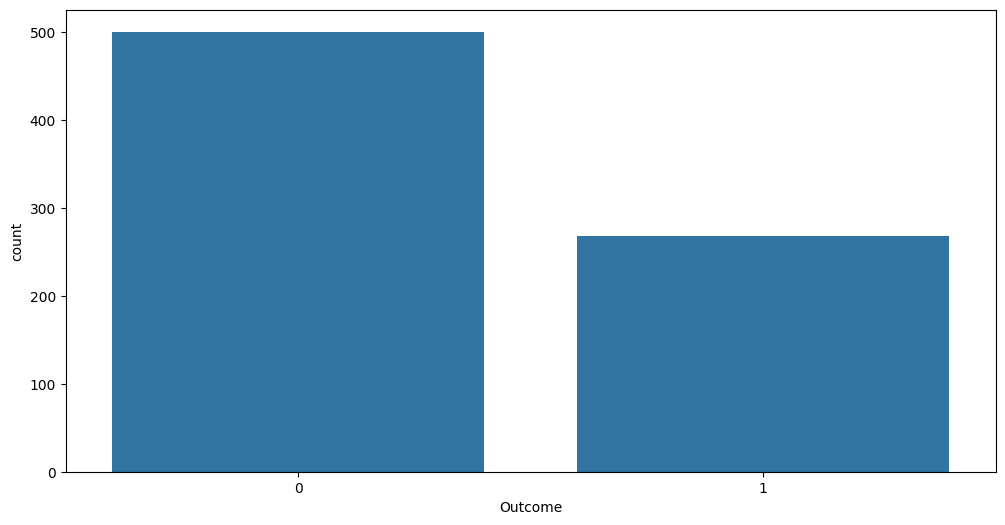

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Outcome', data=df)
plt.show()

# EDA Data Analysis

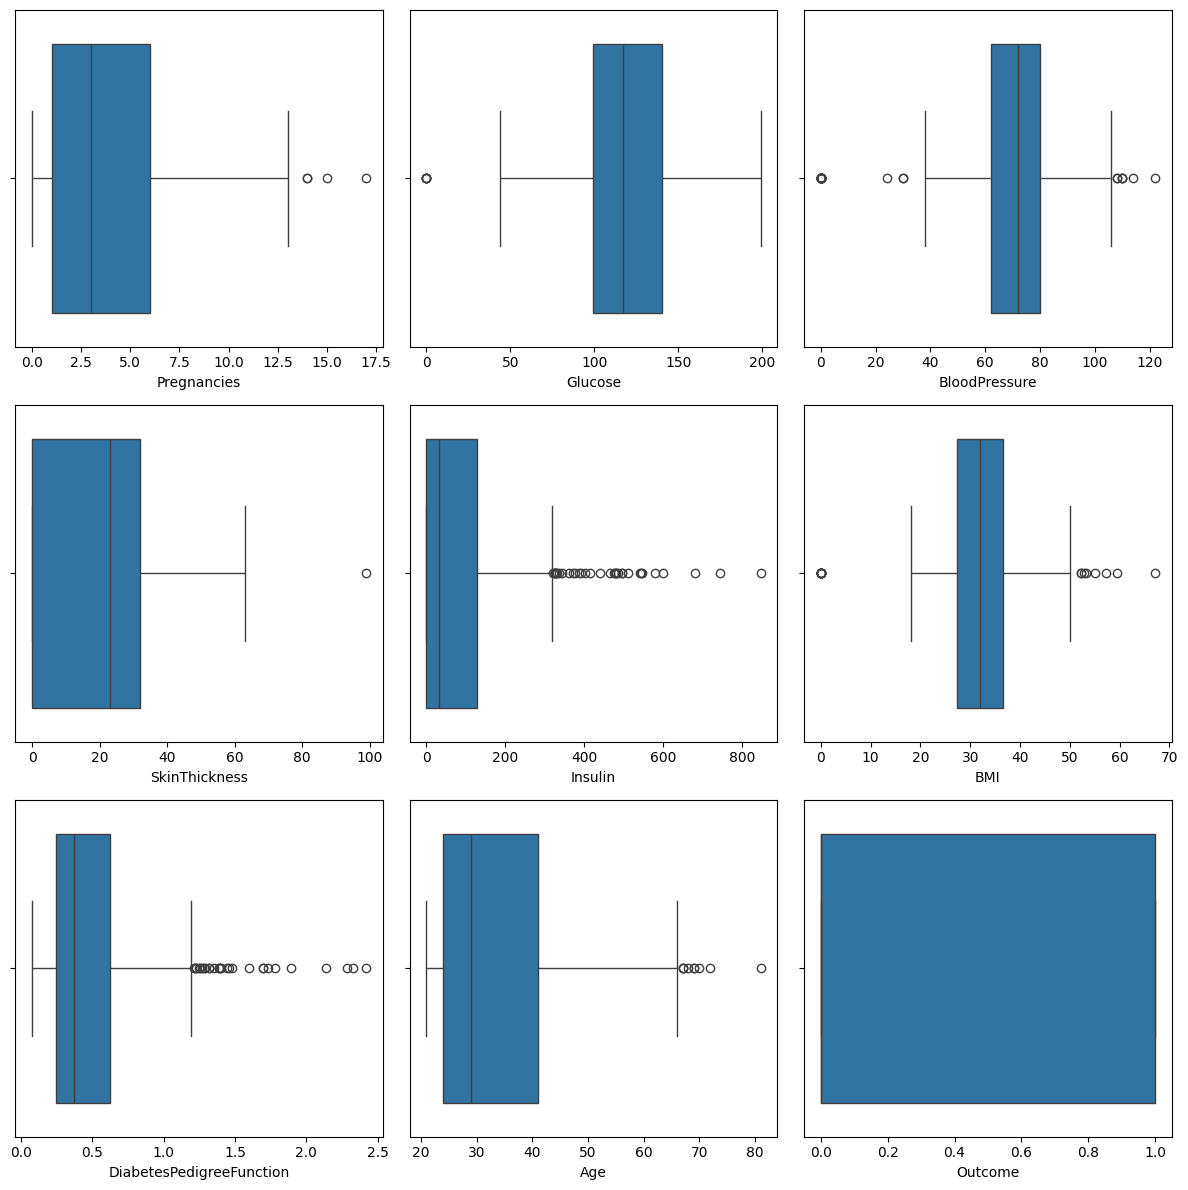

In [ ]:
#observing outliers
plt.figure(figsize=(12,12))
for i, col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=col, data=df)
plt.tight_layout()
plt.show()

In [ ]:
# Fix outliers using the IQR method
for col in df.columns:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Compute the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers below the lower bound with the lower bound
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

    # Replace outliers above the upper bound with the upper bound
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

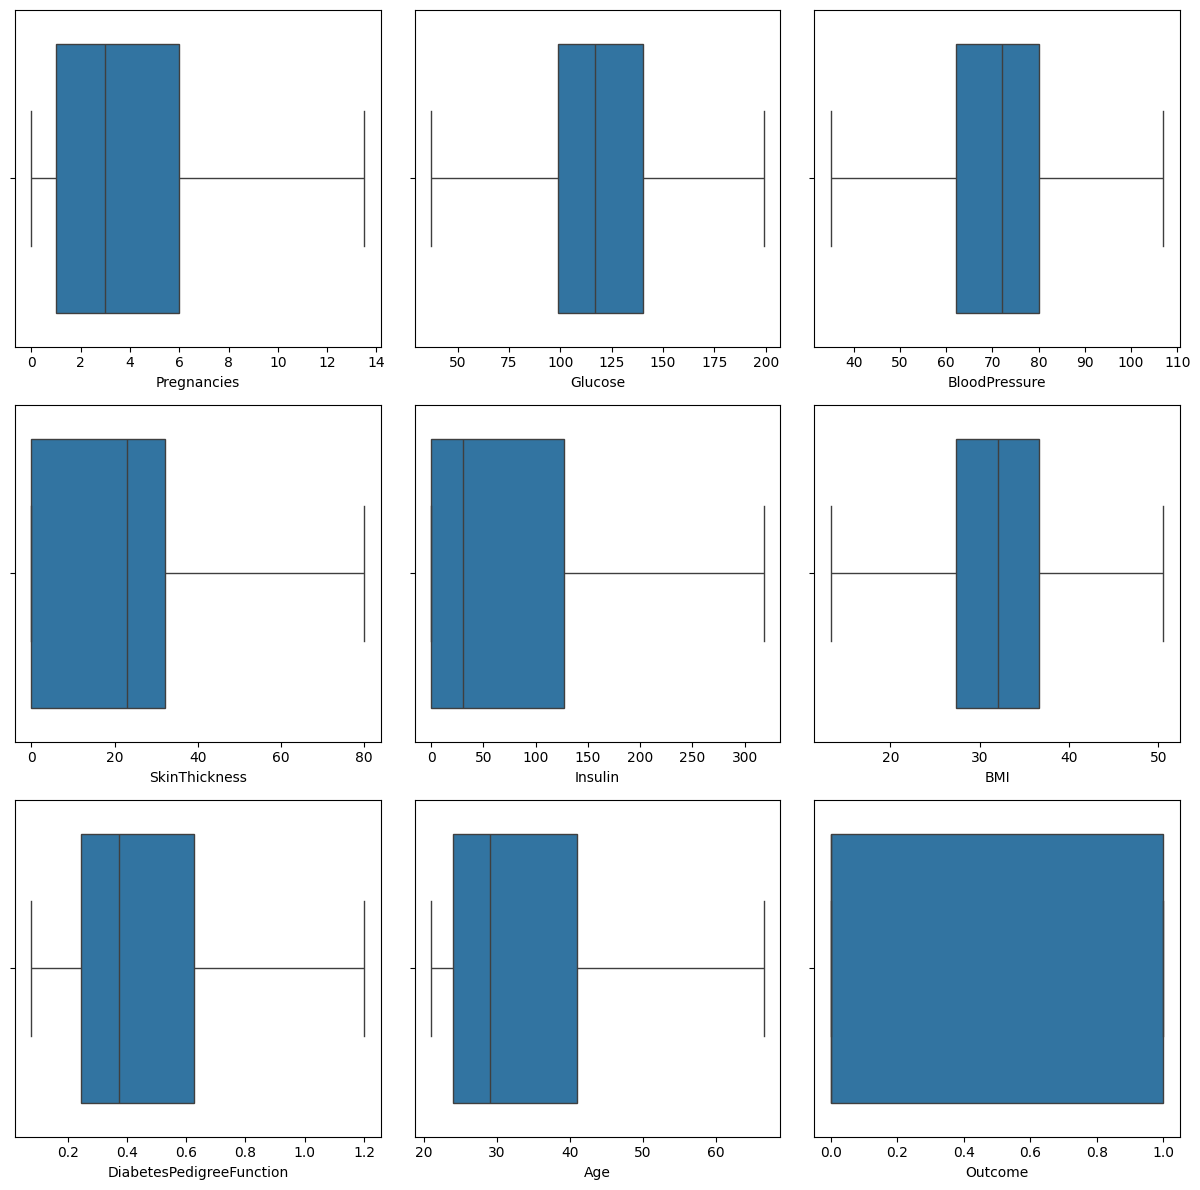

In [ ]:
# Display boxplots after fixing outliers
plt.figure(figsize=(12, 12))
for i, col in enumerate(df.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
plt.tight_layout()
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

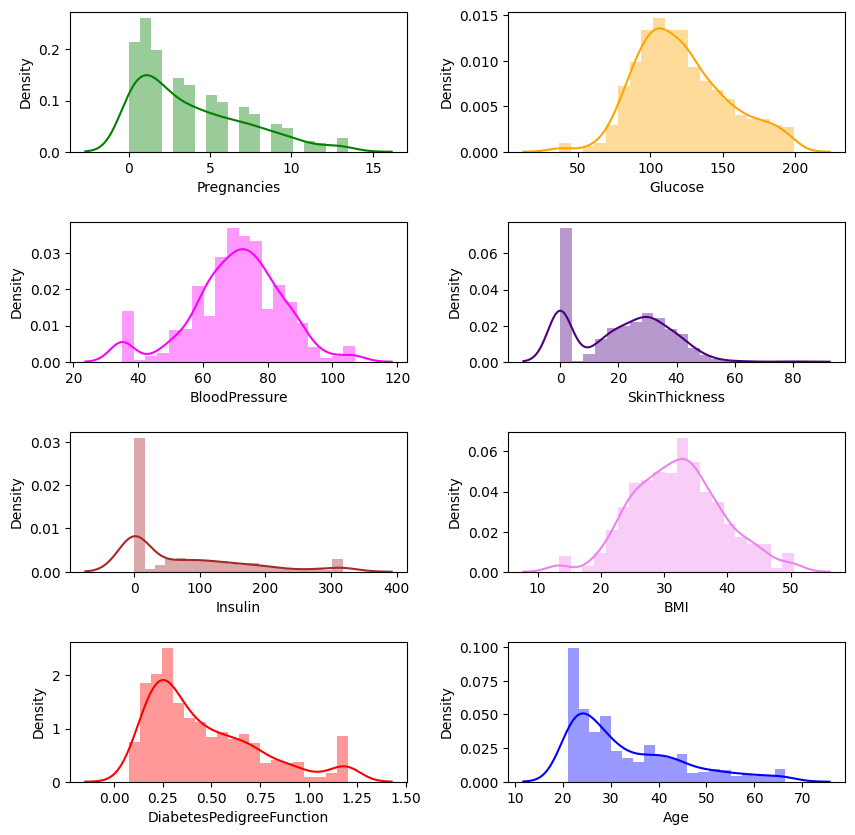

In [ ]:
#Density Graph
fig,axis = plt.subplots(4,2,figsize=(10,10))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

sns.distplot(df.Pregnancies, bins=20, ax = axis[0,0], color="green")
sns.distplot(df.Glucose, bins=20, ax = axis[0,1], color="orange")
sns.distplot(df.BloodPressure, bins=20, ax = axis[1,0], color="magenta")
sns.distplot(df.SkinThickness, bins=20, ax = axis[1,1], color="indigo")
sns.distplot(df.Insulin, bins=20, ax = axis[2,0], color="brown")
sns.distplot(df.BMI, bins=20, ax = axis[2,1], color="violet")
sns.distplot(df.DiabetesPedigreeFunction, bins=20, ax = axis[3,0], color="red")
sns.distplot(df.Age, bins=20, ax = axis[3,1], color="blue")

<Axes: xlabel='Age', ylabel='Count'>

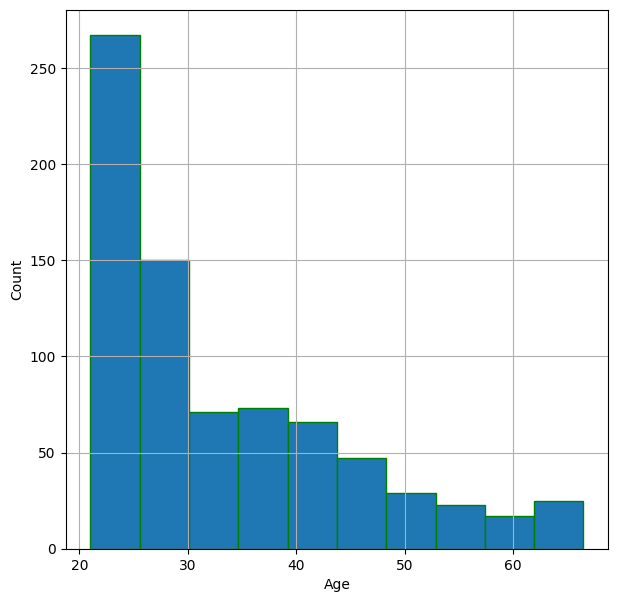

In [ ]:
#Plotting the Histogram of the Ages
plt.figure(figsize=(7,7))
plt.xlabel('Age', fontsize=10)
plt.ylabel('Count', fontsize=10)
df['Age'].hist(edgecolor="green")

In [ ]:
print(df.groupby("Outcome").agg({'Pregnancies':'max'}))
print(df.groupby("Outcome").agg({'Pregnancies':'mean'}))

         Pregnancies
Outcome             
0.0             13.0
1.0             13.5
         Pregnancies
Outcome             
0.0         3.298000
1.0         4.843284


In [ ]:
print(df.groupby("Outcome").agg({'Insulin':'max'}))
print(df.groupby("Outcome").agg({'Insulin':'mean'}))

         Insulin
Outcome         
0.0      318.125
1.0      318.125
           Insulin
Outcome           
0.0      65.113750
1.0      89.583489


In [ ]:
print(df.groupby("Outcome").agg({'DiabetesPedigreeFunction':'max'}))
print(df.groupby("Outcome").agg({'DiabetesPedigreeFunction':'mean'}))

         DiabetesPedigreeFunction
Outcome                          
0.0                           1.2
1.0                           1.2
         DiabetesPedigreeFunction
Outcome                          
0.0                      0.420264
1.0                      0.531022


In [ ]:
print(df.groupby("Outcome").agg({'Glucose':'max'}))
print(df.groupby("Outcome").agg({'Glucose':'mean'}))

         Glucose
Outcome         
0.0        197.0
1.0        199.0
            Glucose
Outcome            
0.0      110.202750
1.0      141.534515


In [ ]:
print(df.groupby("Outcome").agg({'Age':'max'}))
print(df.groupby("Outcome").agg({'Age':'mean'}))

          Age
Outcome      
0.0      66.5
1.0      66.5
               Age
Outcome           
0.0      31.135000
1.0      37.052239


In [ ]:
print(df.groupby("Outcome").agg({'BMI':'max'}))
print(df.groupby("Outcome").agg({'BMI':'mean'}))

           BMI
Outcome       
0.0      50.55
1.0      50.55
               BMI
Outcome           
0.0      30.527500
1.0      35.105597


In [ ]:
print(df.groupby("Outcome").agg({'BloodPressure':'max'}))
print(df.groupby("Outcome").agg({'BloodPressure':'mean'}))

         BloodPressure
Outcome               
0.0              107.0
1.0              107.0
         BloodPressure
Outcome               
0.0          69.508000
1.0          72.880597


In [ ]:
print(df.groupby("Outcome").agg({'SkinThickness':'max'}))
print(df.groupby("Outcome").agg({'SkinThickness':'mean'}))

         SkinThickness
Outcome               
0.0               60.0
1.0               80.0
         SkinThickness
Outcome               
0.0          19.664000
1.0          22.093284


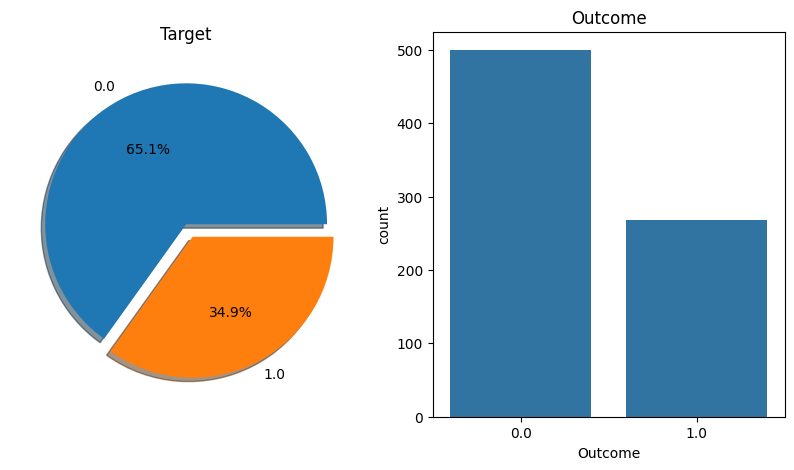

In [ ]:
# Non Diabetic & Diabetic Cases
f, ax = plt.subplots(1, 2, figsize=(10, 5))

# Pie chart
df['Outcome'].value_counts().plot.pie(explode=[0, 0.1], autopct="%1.1f%%", ax=ax[0], shadow=True)
ax[0].set_title('Target')
ax[0].set_ylabel('')

# Count plot
sns.countplot(x='Outcome', data=df, ax=ax[1])
ax[1].set_title('Outcome')

plt.show()

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.136230,70.684896,20.511719,73.652669,32.125065,0.458914,33.199870,0.348958
std,3.344157,31.187468,14.197239,15.844744,93.576029,7.049584,0.285596,11.628404,0.476951
min,0.000000,37.125000,35.000000,0.000000,0.000000,13.350000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,107.000000,80.000000,318.125000,50.550000,1.200000,66.500000,1.000000


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


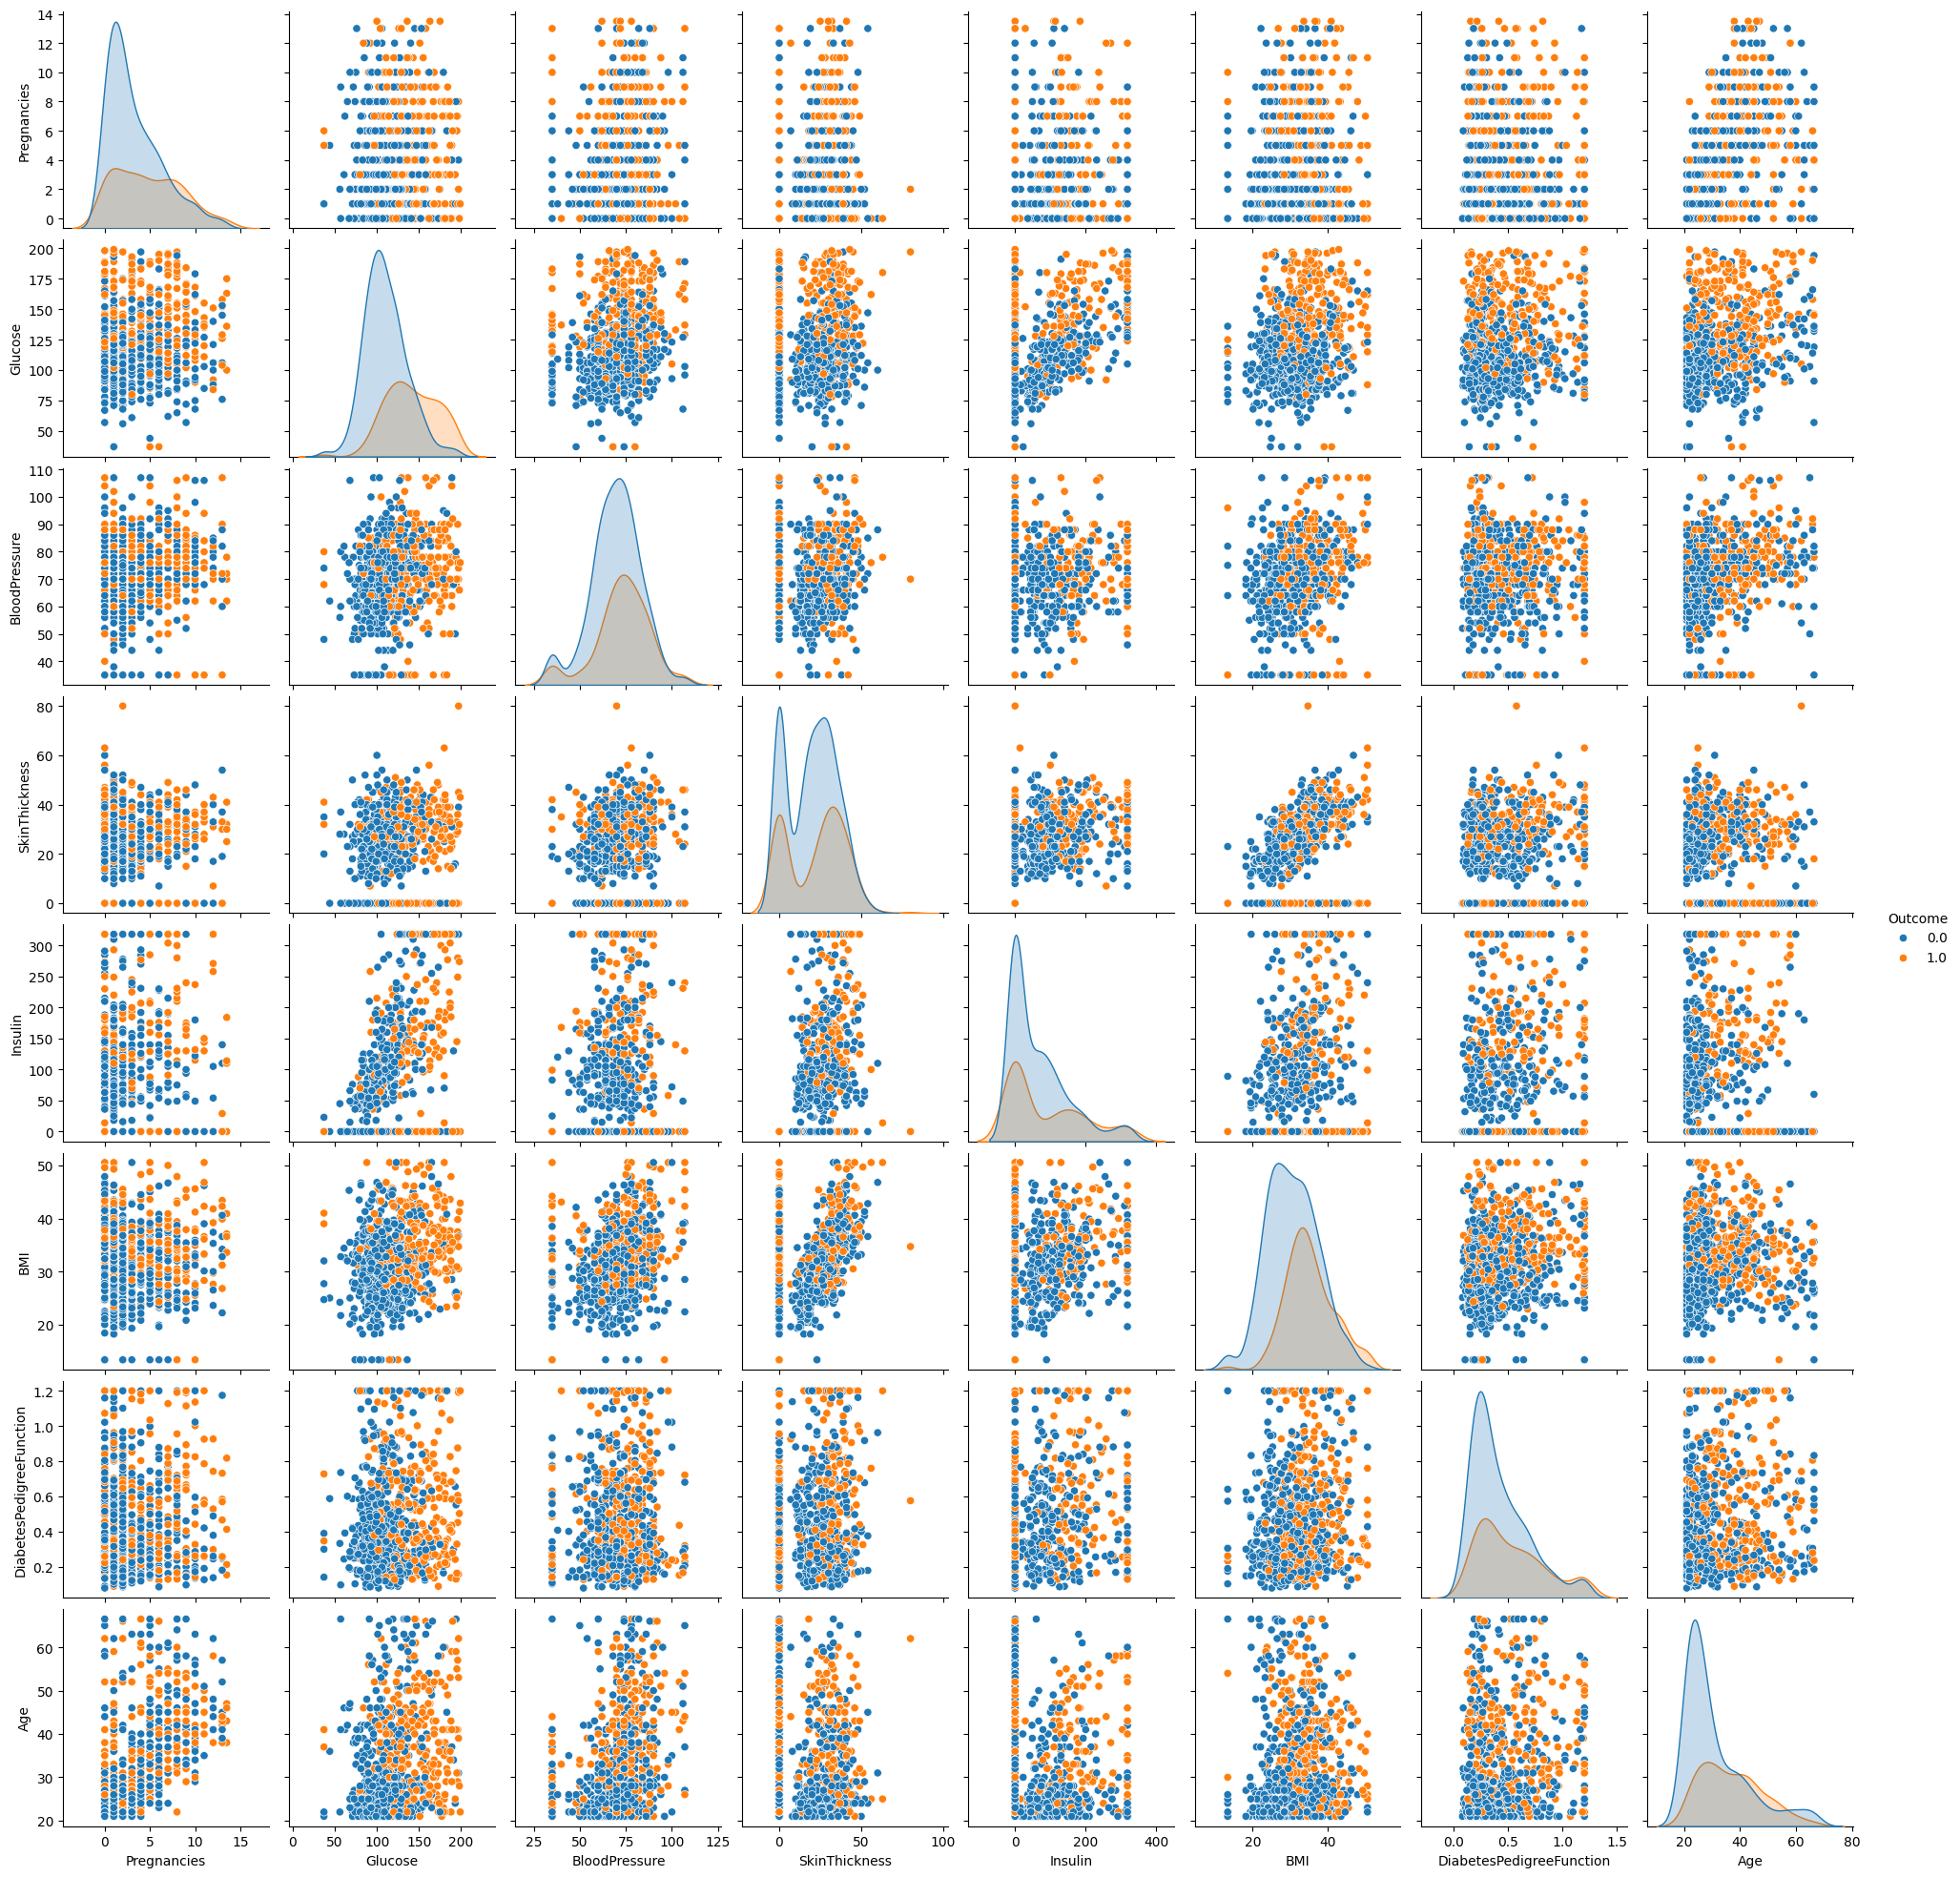

In [ ]:
p = sns.pairplot(df, hue="Outcome")

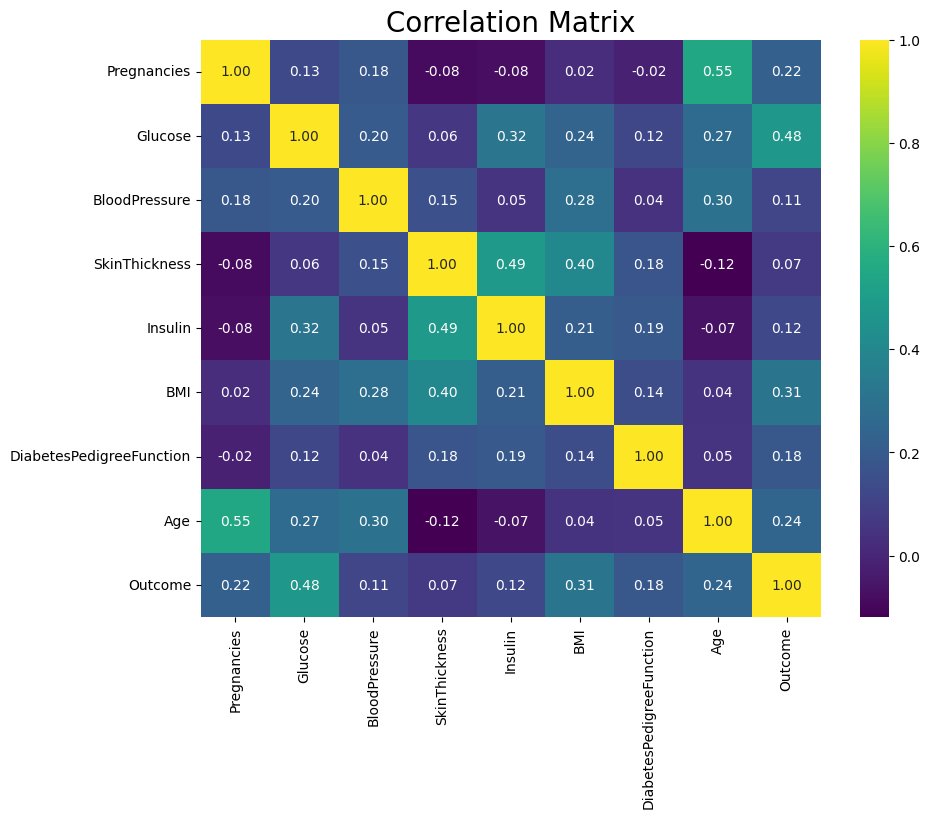

In [ ]:
f,ax = plt.subplots(figsize=[10,7.5])
sns.heatmap(df.corr(), annot=True, fmt = '.2f', ax=ax, cmap='viridis')
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

# Build Model, Training & Transform Data

In [ ]:
x = df.drop(columns = 'Outcome', axis = 1)
y = df['Outcome']

In [ ]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


In [ ]:
y.head()

,Outcome
0,1.0
1,0.0
2,1.0
3,0.0
4,1.0


In [ ]:
scaler = StandardScaler()
scaler.fit(x)
standardized_data = scaler.transform(x)

In [ ]:
print(standardized_data)

[[ 0.64714967  0.86192556  0.09269135 ...  0.20935933  0.58892732
   1.44569096]
 [-0.84896998 -1.15943299 -0.33020145 ... -0.78425421 -0.37810147
  -0.189304  ]
 [ 1.24559754  1.98490253 -0.47116571 ... -1.25267202  0.74659506
  -0.10325164]
 ...
 [ 0.34792574 -0.00437096  0.09269135 ... -0.84103213 -0.74949659
  -0.27535637]
 [-0.84896998  0.15605432 -0.75309424 ... -0.28744744 -0.38510892
   1.18753386]
 [-0.84896998 -0.90275254 -0.04827292 ... -0.24486401 -0.50423566
  -0.87772293]]


In [ ]:
x = standardized_data
y = df['Outcome']
print(x)
print(y)

[[ 0.64714967  0.86192556  0.09269135 ...  0.20935933  0.58892732
   1.44569096]
 [-0.84896998 -1.15943299 -0.33020145 ... -0.78425421 -0.37810147
  -0.189304  ]
 [ 1.24559754  1.98490253 -0.47116571 ... -1.25267202  0.74659506
  -0.10325164]
 ...
 [ 0.34792574 -0.00437096  0.09269135 ... -0.84103213 -0.74949659
  -0.27535637]
 [-0.84896998  0.15605432 -0.75309424 ... -0.28744744 -0.38510892
   1.18753386]
 [-0.84896998 -0.90275254 -0.04827292 ... -0.24486401 -0.50423566
  -0.87772293]]
0      1.0
1      0.0
2      1.0
3      0.0
4      1.0
      ... 
763    0.0
764    0.0
765    0.0
766    1.0
767    0.0
Name: Outcome, Length: 768, dtype: float64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [ ]:
x_train.shape

(614, 8)

In [ ]:
y_train.shape

(614,)

In [ ]:
x_test.shape

(154, 8)

In [ ]:
y_test.shape

(154,)

# Naive Bayes

In [ ]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

GaussianNB()

In [ ]:
y_pred = gnb.predict(x_test)

In [ ]:
y_pred

array([1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0.,
       1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0.])

In [ ]:
y_test

,Outcome
661,1.0
122,0.0
113,0.0
14,1.0
529,0.0
...,...
476,1.0
482,0.0
230,1.0
527,0.0


In [ ]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.7727272727272727


In [ ]:
print("Accuracy Comes In Naive Bayes: {:.3f} %".format(acc*100))

Accuracy Comes In Naive Bayes: 77.273 %


Confusion Matrix:
 [[89 18]
 [17 30]]


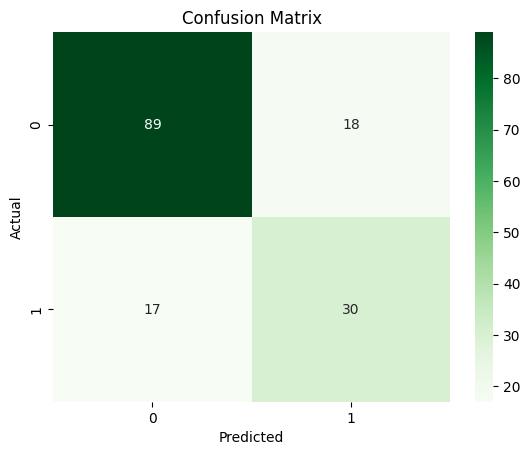

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.83      0.84       107
         1.0       0.62      0.64      0.63        47

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

#Logistic Regression

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lr_model.predict(x_test)

In [ ]:
y_pred

array([1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0.])

In [ ]:
y_test

,Outcome
661,1.0
122,0.0
113,0.0
14,1.0
529,0.0
...,...
476,1.0
482,0.0
230,1.0
527,0.0


In [ ]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.8181818181818182


In [ ]:
print("Accuracy Comes In Logistic Regression: {:.3f} %".format(acc*100))

Accuracy Comes In Logistic Regression: 81.818 %


Confusion Matrix:
 [[97 10]
 [18 29]]


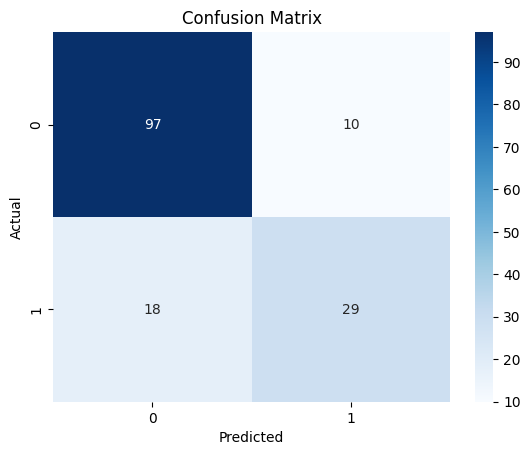

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.91      0.87       107
         1.0       0.74      0.62      0.67        47

    accuracy                           0.82       154
   macro avg       0.79      0.76      0.77       154
weighted avg       0.81      0.82      0.81       154



In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

# K Nearest Neighbours

In [ ]:
knn_model = KNeighborsClassifier()
knn_model.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn_model.predict(x_test)

In [ ]:
y_pred

array([1., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [ ]:
y_test

,Outcome
661,1.0
122,0.0
113,0.0
14,1.0
529,0.0
...,...
476,1.0
482,0.0
230,1.0
527,0.0


In [ ]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.7922077922077922


In [ ]:
print("Accuracy Comes In K Nearest Neighbours: {:.3f} %".format(acc*100))

Accuracy Comes In K Nearest Neighbours: 79.221 %


Confusion Matrix:
 [[94 13]
 [19 28]]


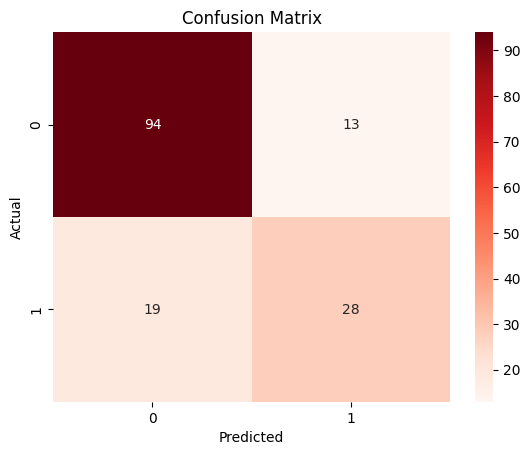

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.88      0.85       107
         1.0       0.68      0.60      0.64        47

    accuracy                           0.79       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.79      0.79      0.79       154



In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

# Random Forest

In [ ]:
fill_values = Imputer(missing_values=0, strategy="mean")

x_train = fill_values.fit_transform(x_train)
x_test = fill_values.fit_transform(x_test)

In [ ]:
random_forest_model = RandomForestClassifier(random_state=10)

random_forest_model.fit(x_train, y_train.ravel())

RandomForestClassifier(random_state=10)

In [ ]:
y_pred = random_forest_model.predict(x_test)

In [ ]:
y_pred

array([1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1.,
       0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [ ]:
y_test

,Outcome
661,1.0
122,0.0
113,0.0
14,1.0
529,0.0
...,...
476,1.0
482,0.0
230,1.0
527,0.0


In [ ]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.8116883116883117


In [ ]:
print("Accuracy Comes In Random Forest: {:.3f} %".format(acc*100))

Accuracy Comes In Random Forest: 81.169 %


Confusion Matrix:
 [[93 14]
 [15 32]]


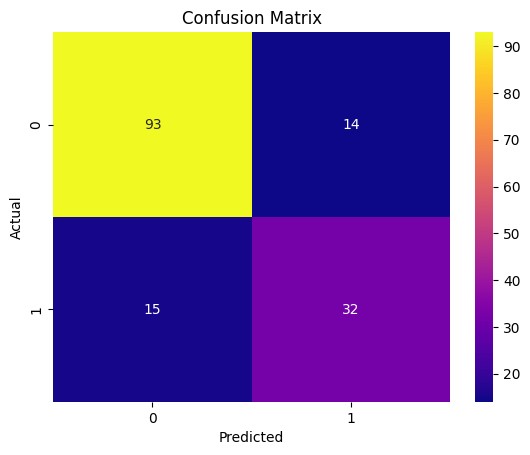

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.87      0.87       107
         1.0       0.70      0.68      0.69        47

    accuracy                           0.81       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154



In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, cmap='plasma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

# Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt_model.predict(x_test)

In [ ]:
y_pred

array([1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1.,
       1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

In [ ]:
y_test

,Outcome
661,1.0
122,0.0
113,0.0
14,1.0
529,0.0
...,...
476,1.0
482,0.0
230,1.0
527,0.0


In [ ]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.7662337662337663


In [ ]:
print("Accuracy Comes In Decision Tree: {:.3f} %".format(acc*100))

Accuracy Comes In Decision Tree: 76.623 %


Confusion Matrix:
 [[86 21]
 [15 32]]


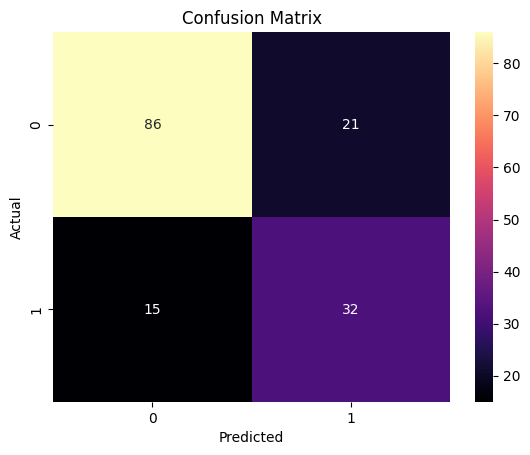

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.80      0.83       107
         1.0       0.60      0.68      0.64        47

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.78      0.77      0.77       154



In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

# SVM

In [ ]:
#svm

In [ ]:
svc = SVC(probability=True)
parameter = {
    "gamma":[0.0001, 0.001, 0.01, 0.1],
    'C': [0.01, 0.05,0.5, 0.01, 1, 10, 15, 20]
}
grid_search = GridSearchCV(svc, parameter)
grid_search.fit(x_train, y_train)

GridSearchCV(estimator=SVC(probability=True),
             param_grid={'C': [0.01, 0.05, 0.5, 0.01, 1, 10, 15, 20],
                         'gamma': [0.0001, 0.001, 0.01, 0.1]})

In [ ]:
# best_parameter
grid_search.best_params_

{'C': 10, 'gamma': 0.01}

In [ ]:
grid_search.best_score_

0.767173130747701

In [ ]:


# Create the SVC model with specified hyperparameters
svc = SVC(C=10, gamma=0.01, probability=True)

# Train the model on the training data
svc.fit(x_train, y_train)

# Make predictions on the training data
y_train_pred = svc.predict(x_train)

# Make predictions on the test data
y_test_pred = svc.predict(x_test)

# Calculate accuracy for training and test data
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print(f"Accuracy on Training Data: {train_accuracy:.2f}")
print(f"Accuracy on Test Data: {test_accuracy:.2f}")

print("Accuracy Comes In SVM: {:.3f} %".format(test_accuracy*100))




Accuracy on Training Data: 0.78
Accuracy on Test Data: 0.82
Accuracy Comes In SVM: 82.468 %


Confusion Matrix:
 [[99  8]
 [19 28]]


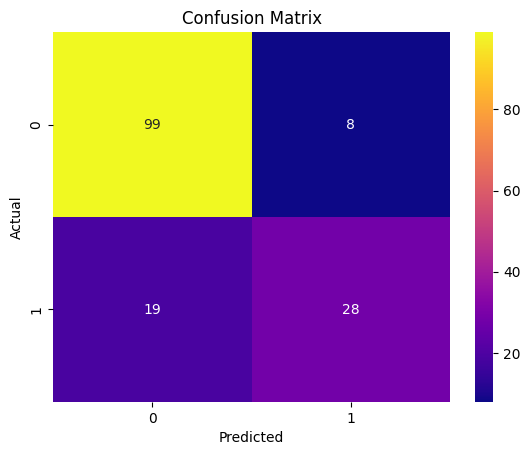

In [ ]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)
sns.heatmap(conf_matrix, annot=True, cmap='plasma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))
# Print classification report for test data
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.80      0.83       107
         1.0       0.60      0.68      0.64        47

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.78      0.77      0.77       154


Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88       107
         1.0       0.78      0.60      0.67        47

    accuracy                           0.82       154
   macro avg       0.81      0.76      0.78       154
weighted avg       0.82      0.82      0.82       154



# Gradient Boosting

In [ ]:
#gradient boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the GradientBoostingClassifier
gbc = GradientBoostingClassifier()

# Define the parameter grid
parameters = {
    'loss': ['log_loss'],
    'learning_rate': [0.001, 0.1, 1, 10],  # Learning rate values for experimentation
    'n_estimators': [100, 150, 180, 200]  # Number of trees in the ensemble
}

# Set up GridSearchCV for hyperparameter tuning
grid_search_gbc = GridSearchCV(
    estimator=gbc,
    param_grid=parameters,
    cv=10,  # 10-fold cross-validation
    n_jobs=-1,  # Use all available processors
    verbose=1  # Display progress during the search
)

# Fit the model on training data
grid_search_gbc.fit(x_train, y_train)




Fitting 10 folds for each of 16 candidates, totalling 160 fits


GridSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.1, 1, 10],
                         'loss': ['log_loss'],
                         'n_estimators': [100, 150, 180, 200]},
             verbose=1)

In [ ]:
grid_search_gbc.best_params_

{'learning_rate': 0.1, 'loss': 'log_loss', 'n_estimators': 100}

In [ ]:
grid_search_gbc.best_score_

0.750846113167636

In [ ]:
gbc = GradientBoostingClassifier(learning_rate = 0.1, loss = 'log_loss', n_estimators = 100)
gbc.fit(x_train, y_train)

GradientBoostingClassifier()

In [ ]:
# Get the best estimator from the grid search
gbc = grid_search_gbc.best_estimator_

# Make predictions on the training data
y_train_pred = gbc.predict(x_train)

# Make predictions on the test data
y_test_pred = gbc.predict(x_test)

# Calculate accuracy for both the training and test data
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print(f"Accuracy on Training Data: {train_accuracy:.2f}")
print(f"Accuracy on Test Data: {test_accuracy:.2f}")
print("Accuracy Comes In GBC: {:.3f} %".format(test_accuracy*100))




Accuracy on Training Data: 0.91
Accuracy on Test Data: 0.81
Accuracy Comes In GBC: 80.519 %


Confusion Matrix:
 [[93 14]
 [16 31]]


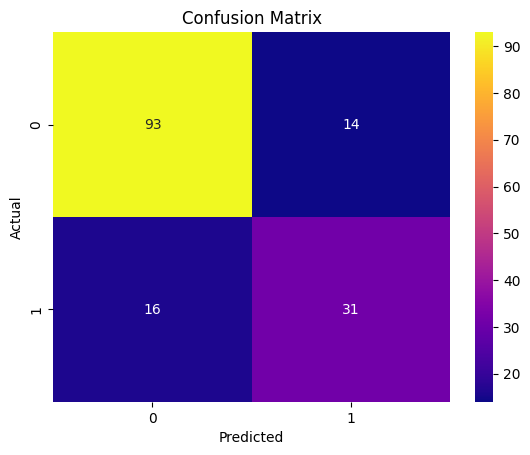

In [ ]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", conf_matrix)

sns.heatmap(conf_matrix, annot=True, cmap='plasma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))
# Print classification report for test data
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.80      0.83       107
         1.0       0.60      0.68      0.64        47

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.78      0.77      0.77       154


Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.87      0.86       107
         1.0       0.69      0.66      0.67        47

    accuracy                           0.81       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.80      0.81      0.80       154



# Model Comparison: Performance Evaluation on Training and Test Data

In [ ]:
# List of models to compare
models = {
    'Naive Bayes': gnb,
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'Random Forest': random_forest_model,
    'Decision Tree': dt_model,
    'SVM': svc,
    'Gradient Boosting': gbc,
}

# Lists to store model results
model_names = []
train_accuracies = []
test_accuracies = []
accuracy_differences = []

# Evaluate each model
for model_name, model in models.items():
    # Predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    accuracy_diff = abs(train_accuracy - test_accuracy)  # Measure balance

    # Store results
    model_names.append(model_name)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    accuracy_differences.append(accuracy_diff)

    # Print model performance
    print(f"Model: {model_name}")
    print(f"Accuracy on Training Data: {train_accuracy:.2f}")
    print(f"Accuracy on Test Data: {test_accuracy:.2f}")
    print(f"Difference (Train - Test): {accuracy_diff:.2f}")
    print("-" * 50)

Model: Naive Bayes
Accuracy on Training Data: 0.75
Accuracy on Test Data: 0.77
Difference (Train - Test): 0.03
--------------------------------------------------
Model: Logistic Regression
Accuracy on Training Data: 0.76
Accuracy on Test Data: 0.82
Difference (Train - Test): 0.06
--------------------------------------------------
Model: KNN
Accuracy on Training Data: 0.82
Accuracy on Test Data: 0.79
Difference (Train - Test): 0.02
--------------------------------------------------
Model: Random Forest
Accuracy on Training Data: 1.00
Accuracy on Test Data: 0.81
Difference (Train - Test): 0.19
--------------------------------------------------
Model: Decision Tree
Accuracy on Training Data: 1.00
Accuracy on Test Data: 0.77
Difference (Train - Test): 0.23
--------------------------------------------------
Model: SVM
Accuracy on Training Data: 0.78
Accuracy on Test Data: 0.82
Difference (Train - Test): 0.04
--------------------------------------------------
Model: Gradient Boosting
Accurac


Ranking of Models Based on Test Accuracy:
Rank 1: SVM - Test Accuracy: 0.82
Rank 2: Logistic Regression - Test Accuracy: 0.82
Rank 3: Random Forest - Test Accuracy: 0.81
Rank 4: Gradient Boosting - Test Accuracy: 0.81
Rank 5: KNN - Test Accuracy: 0.79
Rank 6: Naive Bayes - Test Accuracy: 0.77
Rank 7: Decision Tree - Test Accuracy: 0.77


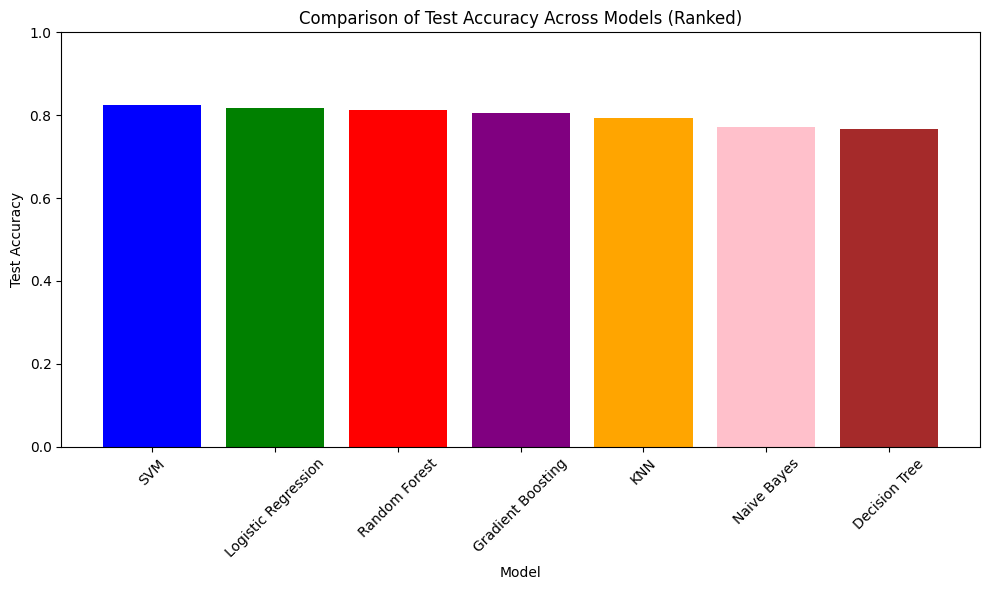

In [ ]:
# Sorting the models by test accuracy in descending order
sorted_models = sorted(zip(model_names, test_accuracies), key=lambda x: x[1], reverse=True)

# Unzip the sorted models and accuracies
sorted_model_names, sorted_test_accuracies = zip(*sorted_models)
print("\nRanking of Models Based on Test Accuracy:")
for rank, (model, accuracy) in enumerate(zip(sorted_model_names, sorted_test_accuracies), start=1):
    print(f"Rank {rank}: {model} - Test Accuracy: {accuracy:.2f}")

# Plotting the comparison of test accuracies
plt.figure(figsize=(10, 6))
plt.bar(sorted_model_names, sorted_test_accuracies, color=['blue', 'green', 'red', 'purple', 'orange', 'pink', 'brown'])
plt.title('Comparison of Test Accuracy Across Models (Ranked)')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim([0, 1])  # Set the y-axis limit from 0 to 1 (for accuracy)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame({
    'Model': model_names,
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies,
    'Accuracy Difference': accuracy_differences
})

# Sort by accuracy difference
ranked_results = results_df.sort_values(by='Accuracy Difference')
print("\nRanked Models by Accuracy Balance:")
print(ranked_results)


Ranked Models by Accuracy Balance:
                 Model  Train Accuracy  Test Accuracy  Accuracy Difference
2                  KNN        0.815961       0.792208             0.023753
0          Naive Bayes        0.747557       0.772727             0.025170
5                  SVM        0.783388       0.824675             0.041288
1  Logistic Regression        0.762215       0.818182             0.055967
6    Gradient Boosting        0.913681       0.805195             0.108486
3        Random Forest        1.000000       0.811688             0.188312
4        Decision Tree        1.000000       0.766234             0.233766


In [ ]:
# Cross-validation for each model
for model_name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
    print(f"Model: {model_name} - Cross-Validation Accuracy: {cv_scores.mean():.2f}")


Model: Naive Bayes - Cross-Validation Accuracy: 0.74
Model: Logistic Regression - Cross-Validation Accuracy: 0.76
Model: KNN - Cross-Validation Accuracy: 0.71
Model: Random Forest - Cross-Validation Accuracy: 0.75
Model: Decision Tree - Cross-Validation Accuracy: 0.68
Model: SVM - Cross-Validation Accuracy: 0.77
Model: Gradient Boosting - Cross-Validation Accuracy: 0.75


In [ ]:
for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_test_pred = model.predict(x_test)

    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    print(f"\n{model_name} - Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")



Naive Bayes - Precision: 0.62, Recall: 0.64, F1-Score: 0.63

Logistic Regression - Precision: 0.74, Recall: 0.62, F1-Score: 0.67

KNN - Precision: 0.68, Recall: 0.60, F1-Score: 0.64

Random Forest - Precision: 0.70, Recall: 0.68, F1-Score: 0.69

Decision Tree - Precision: 0.65, Recall: 0.72, F1-Score: 0.69

SVM - Precision: 0.78, Recall: 0.60, F1-Score: 0.67

Gradient Boosting - Precision: 0.70, Recall: 0.68, F1-Score: 0.69


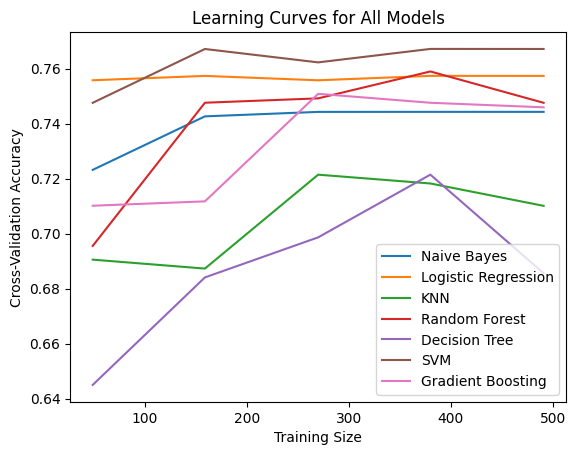

In [ ]:
for model_name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    plt.plot(train_sizes, test_scores.mean(axis=1), label=model_name)

plt.title("Learning Curves for All Models")
plt.xlabel("Training Size")
plt.ylabel("Cross-Validation Accuracy")
plt.legend(loc="best")
plt.show()


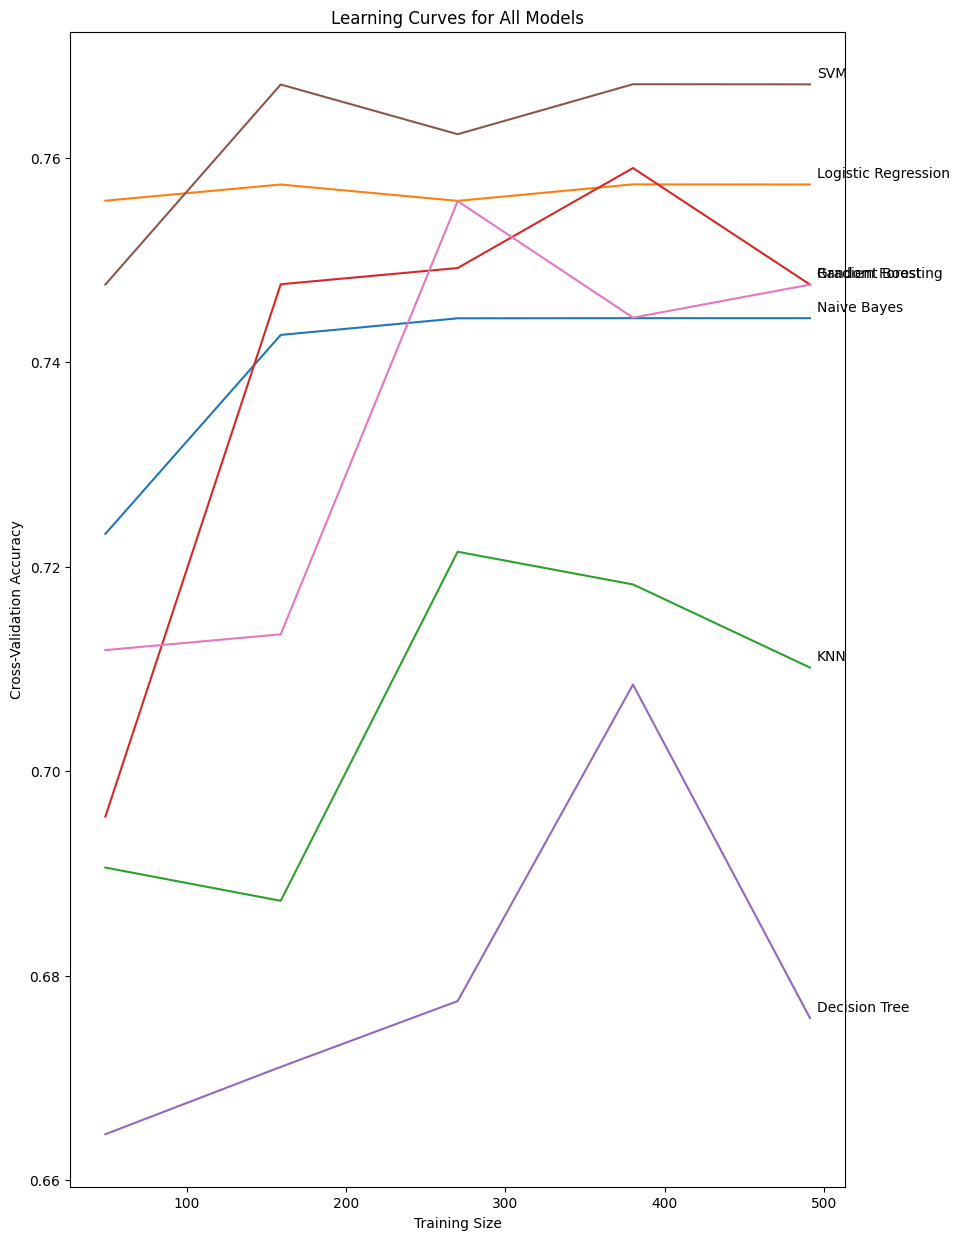

In [ ]:
# # ... (previous code)

# # Set a larger width for the plot
# plt.figure(figsize=(10,15))  # Increased width to 15

# for model_name, model in models.items():
#     train_sizes, train_scores, test_scores = learning_curve(model, x_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
#     plt.plot(train_sizes, test_scores.mean(axis=1), label=model_name)
#     x_coord = train_sizes[-1]
#     y_coord = test_scores.mean(axis=1)[-1]
#     plt.annotate(model_name, (x_coord, y_coord), textcoords="offset points", xytext=(5,5), ha='left')

# plt.title("Learning Curves for All Models")
# plt.xlabel("Training Size")
# plt.ylabel("Cross-Validation Accuracy")
# plt.show()

# # ... (rest of the code)